# Import Library

In [141]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


# 1) Load ảnh 

                 detail_hf_meanabs  noise_sigma_mad  detail_grad_mean  blur_lap_var  edge_density   entropy    H    W
image                                                                                                                
sample/BKH6.jpg           3.997084         2.965200         52.660450    726.525879      0.076610  7.619304  443  665
sample/BKH1.jpg           8.775925         8.895599         95.673347   2479.034180      0.219015  7.640097  720  960
sample/BKA4.jpg          13.207874        10.378200        141.113235   6729.353516      0.211794  7.657583  367  700

Saved: output/image_metrics.csv


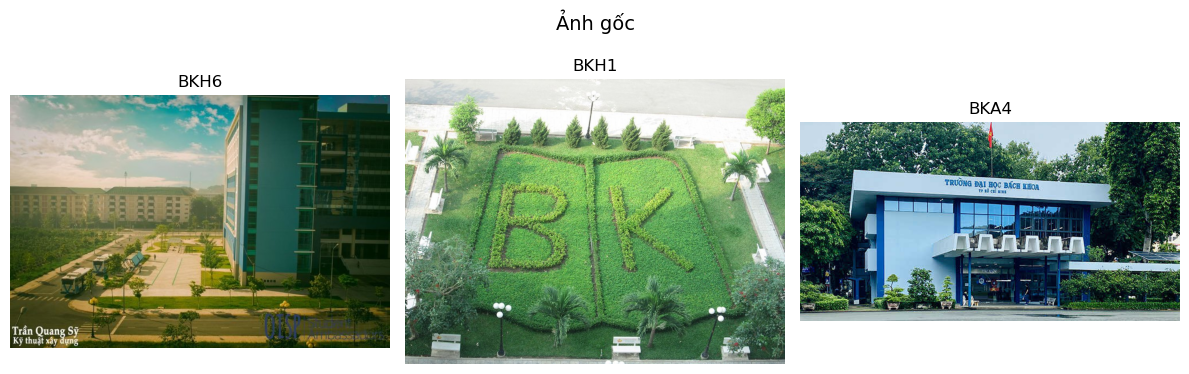

In [147]:
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

image_paths = [
    "sample/BKH6.jpg",
    "sample/BKH1.jpg",
    "sample/BKA4.jpg",
]

def safe_read_gray(image_path: str) -> np.ndarray:
    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return gray

def image_entropy(gray: np.ndarray, bins: int = 256) -> float:
    hist = cv2.calcHist([gray], [0], None, [bins], [0, 256]).ravel().astype(np.float64)
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def compute_metrics(gray: np.ndarray, hp_sigma: float = 1.0,
                    canny1: int = 100, canny2: int = 200) -> dict:
    gray_f = gray.astype(np.float32)

    # --- High-pass (Gaussian) ---
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=hp_sigma)
    hp = gray_f - blur.astype(np.float32)

    # Detail score (high-frequency energy)
    detail_hf_meanabs = float(np.mean(np.abs(hp)))

    # Noise estimate (MAD on high-pass)
    med = np.median(hp)
    mad = np.median(np.abs(hp - med))
    noise_sigma = float(1.4826 * mad) 

    # --- Gradient energy (2D) ---
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = cv2.magnitude(gx, gy)
    detail_grad_mean = float(np.mean(grad_mag))

    # --- Blur proxy (variance of Laplacian) ---
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    blur_lap_var = float(lap.var()) 

    # --- Edge density (Canny) ---
    edges = cv2.Canny(gray, canny1, canny2)
    edge_density = float(np.mean(edges > 0))

    # --- Entropy ---
    ent = image_entropy(gray)

    return {
        "detail_hf_meanabs": detail_hf_meanabs,
        "noise_sigma_mad": noise_sigma,
        "detail_grad_mean": detail_grad_mean,
        "blur_lap_var": blur_lap_var,
        "edge_density": edge_density,
        "entropy": ent,
    }

rows = []
for p in image_paths:
    gray = safe_read_gray(p)
    m = compute_metrics(gray, hp_sigma=1.0, canny1=100, canny2=200)
    m["image"] = p
    m["H"], m["W"] = gray.shape
    rows.append(m)

df = pd.DataFrame(rows).set_index("image")
pd.set_option("display.expand_frame_repr", False)
print(df)


# Save CSV để bỏ vào report
csv_path = OUT_DIR / "image_metrics.csv"
df.to_csv(csv_path, float_format="%.6f")
print(f"\nSaved: {csv_path}")

def safe_read_color(image_path: str) -> np.ndarray:
    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, len(image_paths), figsize=(12, 4))

for ax, p in zip(axes, image_paths):
    img = safe_read_color(p)
    name = Path(p).stem
    ax.imshow(img)
    ax.set_title(name)     
    ax.axis("off")

fig.suptitle("Ảnh gốc", fontsize=14)

plt.tight_layout()
plt.show()


In [143]:
def float_to_vis_signed(x: np.ndarray) -> np.ndarray:
    """
    High-pass thường có giá trị âm/dương.
    Ta shift về 128 để nhìn rõ: vis = clip(x + 128).
    """
    vis = np.clip(x.astype(np.float32) + 128.0, 0, 255).astype(np.uint8)
    return vis

def float_to_vis_nonneg(x: np.ndarray) -> np.ndarray:
    """Scale về 0..255 cho ảnh không âm (vd: sobel magnitude)."""
    x = x.astype(np.float32)
    m = float(x.max())
    if m < 1e-6:
        return np.zeros_like(x, dtype=np.uint8)
    vis = np.clip(x / m * 255.0, 0, 255).astype(np.uint8)
    return vis

def save_gray(path: Path, img_uint8: np.ndarray):
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), img_uint8)

In [144]:
def apply_filters(gray: np.ndarray):
    gray_f = gray.astype(np.float32)

    # (A) High-pass = Original - Low-pass
    mean_blur = cv2.blur(gray, (5, 5))
    hp_mean = gray_f - mean_blur.astype(np.float32)

    gauss_blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.2)
    hp_gauss = gray_f - gauss_blur.astype(np.float32)

    alpha = 1.5
    sharpen_gauss = np.clip(gray_f + alpha * hp_gauss, 0, 255).astype(np.uint8)

    # (B) Kernel chuẩn: Laplacian, Sobel
    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)

    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    sobel_mag = cv2.magnitude(sx, sy)

    # (C) Kernel tự thiết kế (high-pass 3x3 tổng = 0)
    kernel_hp = np.array(
        [[-1, -1, -1],
         [-1,  8, -1],
         [-1, -1, -1]], dtype=np.float32
    )
    hp_custom = cv2.filter2D(gray, ddepth=cv2.CV_32F, kernel=kernel_hp)

    return {
        "gray": gray,
        "A1_hp_mean": hp_mean,
        "A2_hp_gauss": hp_gauss,
        "A2_sharpen_gauss": sharpen_gauss,
        "B1_laplacian": lap,
        "B2_sobel_mag": sobel_mag,
        "C1_hp_custom": hp_custom,
    }

In [145]:
results = {}

for p in image_paths:
    name = Path(p).stem
    gray = safe_read_gray(p)
    out = apply_filters(gray)
    results[name] = out

    subdir = OUT_DIR / name
    # save original
    save_gray(subdir / "00_gray.png", out["gray"])

    # signed high-pass -> shift 128 for visualization
    save_gray(subdir / "A1_highpass_mean_vis.png", float_to_vis_signed(out["A1_hp_mean"]))
    save_gray(subdir / "A2_highpass_gauss_vis.png", float_to_vis_signed(out["A2_hp_gauss"]))
    save_gray(subdir / "B1_laplacian_vis.png", float_to_vis_signed(out["B1_laplacian"]))
    save_gray(subdir / "C1_highpass_custom_vis.png", float_to_vis_signed(out["C1_hp_custom"]))

    # non-negative -> scale 0..255
    save_gray(subdir / "B2_sobel_mag.png", float_to_vis_nonneg(out["B2_sobel_mag"]))

    # sharpen is uint8 already
    save_gray(subdir / "A2_sharpen_gauss.png", out["A2_sharpen_gauss"])

print("Saved outputs to:", OUT_DIR.resolve())


Saved outputs to: /Users/takut/Downloads/252_CV/ASS/ASS1/output


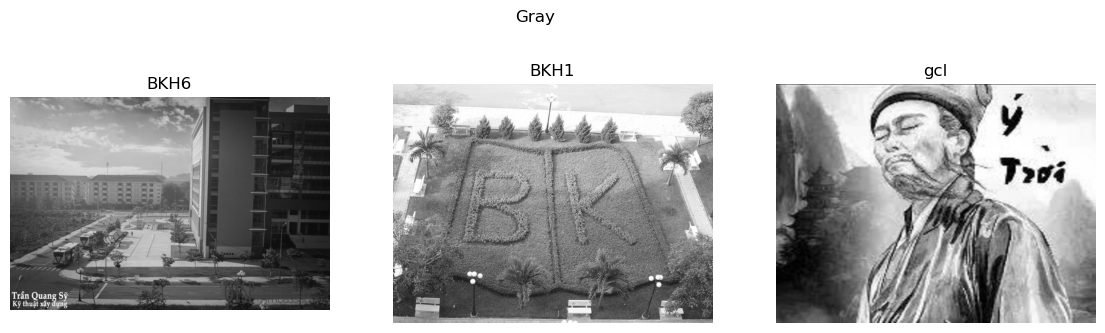

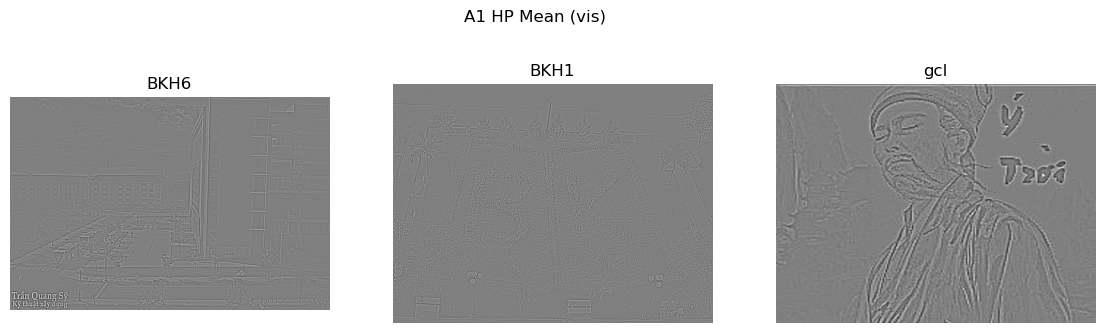

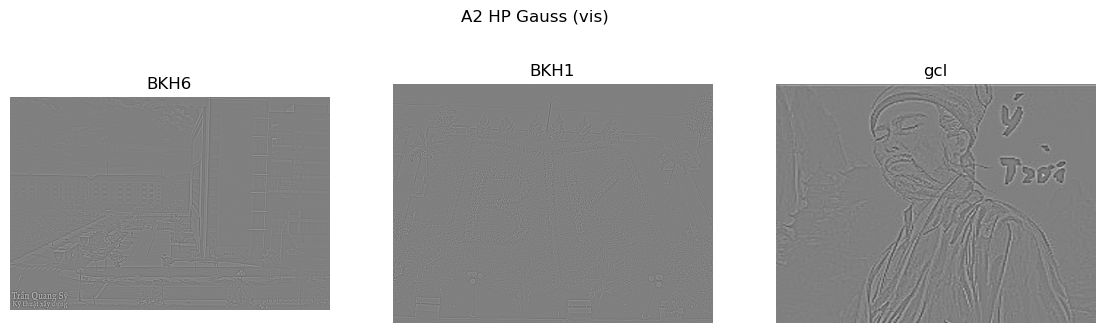

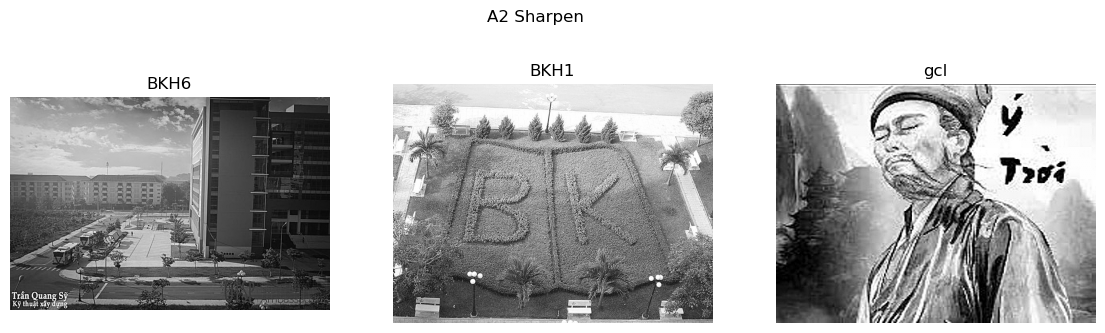

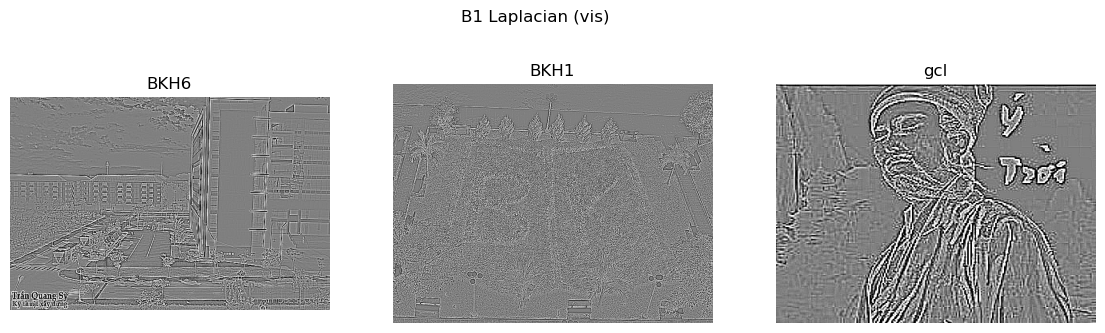

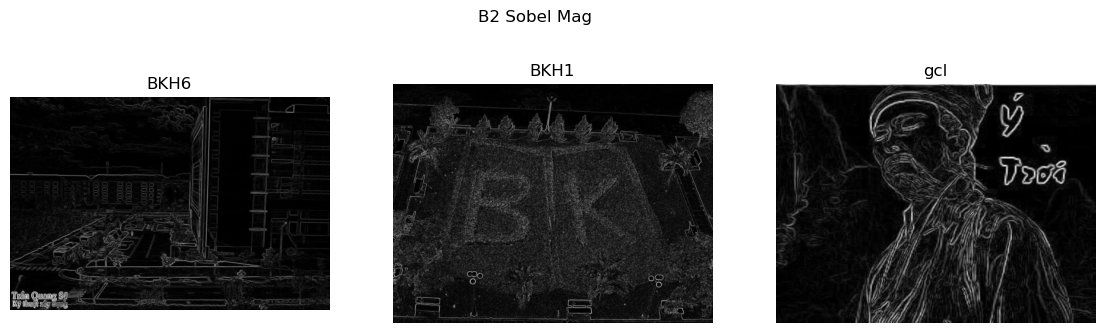

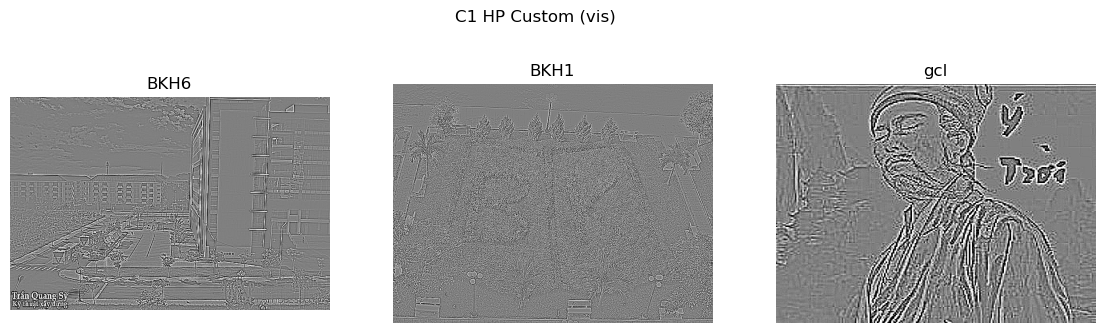

In [146]:
methods = [
    ("Gray",          lambda d: d["gray"]),
    ("A1 HP Mean (vis)", lambda d: float_to_vis_signed(d["A1_hp_mean"])),
    ("A2 HP Gauss (vis)",lambda d: float_to_vis_signed(d["A2_hp_gauss"])),
    ("A2 Sharpen",       lambda d: d["A2_sharpen_gauss"]),
    ("B1 Laplacian (vis)",lambda d: float_to_vis_signed(d["B1_laplacian"])),
    ("B2 Sobel Mag",     lambda d: float_to_vis_nonneg(d["B2_sobel_mag"])),
    ("C1 HP Custom (vis)",lambda d: float_to_vis_signed(d["C1_hp_custom"])),
]

img_names = [Path(p).stem for p in image_paths]

for title, getter in methods:
    plt.figure(figsize=(14, 4))
    for i, nm in enumerate(img_names, 1):
        plt.subplot(1, len(img_names), i)
        plt.imshow(getter(results[nm]), cmap="gray", vmin=0, vmax=255)
        plt.title(nm)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()
